In [2]:
import os
os.sys.path.append('/data/scratch/globc/bonassies/workspace/swot_for_flood')
import geopandas as gpd
import configparser
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
from cmap import Colormap

from core.swot_project import SwotProject
from core.plot_raster import PlotRaster

main_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Ohio"

# Plotting for Ohio

This notebook uses the rasters generated by Ohio_pretreat.ipynb to plot the results of the Ohio exercise. The rasters are stored in the `rasters` folder and the plots are stored in the `plots` folder.

First, we need to load the project:

In [3]:
config = configparser.ConfigParser()
config.read(main_path + '/config.cfg')

# print(type(config),dict(config['CONFIG']))

['/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Ohio/config.cfg']

In [4]:
swot_project = SwotProject(config)
# print(swot_project)

No automatic download, please use the Downloader object to download the data


In [5]:
swot_project.find_raster()


Then, once loaded, we need to create, load and pre-treat the SWOT data used for plotting.
Here we use the collection object within the project to create a new collection with the dry and flooded times selected.

In [6]:
# takes around 2 minutes for 5 raster files of 1.65Go
swot_project.create_collection()

Opening SWOT raster at time: 2025-02-20 18:02:16
Opening SWOT raster at time: 2023-12-10 14:15:25
Opening SWOT raster at time: 2023-09-18 03:15:18
Opening SWOT raster at time: 2024-03-23 22:00:59
Opening SWOT raster at time: 2023-10-29 20:45:25


We can then create the plot object that we will use to plot the data.

In [7]:
plot_obj = PlotRaster(
    swot_project,
    save_fig=True,
    show_fig=True
    )

Finally, we can plot the data using the plot object.

If you want to see the global dataset, you can use the plot_all_rasters function. This function will plot all the rasters in one figure.
It is useful to define dry dates for the mean and observe flooded dates.

In [8]:
# # plot 25 maps in less than 4 minutes for raster files of 1.65Go
# plot_obj.plot_all_rasters(
#     'gamma_tot',
#     cmap=Colormap('seaborn:mako').to_matplotlib(),
#     vmin=0,
#     vmax=1,
# )


Below, a function to plot the control area and histograms associated with the control area.

(<Figure size 1500x500 with 4 Axes>,
 array([<Axes: title={'center': '$\\gamma_{total}$ - Mean data'}, ylabel='Owensboro, USA - Ohio River'>,
        <Axes: title={'center': '$\\gamma_{total}$ - 2025-02-20 18:02'}>,
        <Axes: xlabel='$\\gamma_{total}$'>], dtype=object))

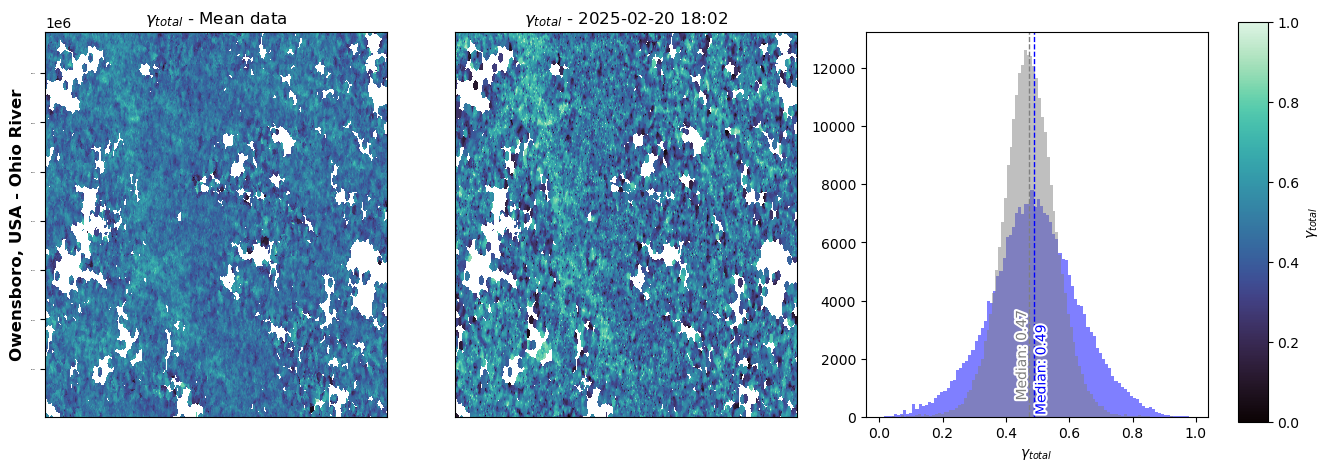

In [27]:
plot_obj.plot_control_maps_and_histograms(
    'gamma_tot', 
    time_selection="2025-02-20",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    y_label="Owensboro, USA - Ohio River",
    vmin=0,
    vmax=1,
    )


Plot mean histograms with the dates that compose the mean.

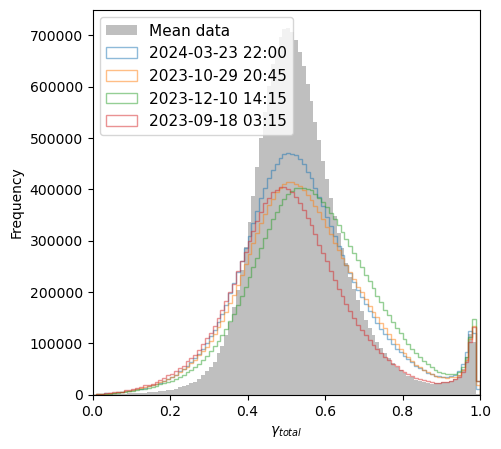

In [32]:
fig,ax = plot_obj.plot_mean_hist_computation(
    'gamma_tot',
    hist_range=(0,1),
    add_legend=True
)

Below, the function to plot a map.

In [ ]:
# takes around 1 minute
fig, ax = plot_obj.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="diff",
    world_cover_selection='urban',
    time_selection="2025-02-20",
    # cmap=Colormap("seaborn:mako").to_matplotlib(),
    cmap=Colormap("cmocean:balance").to_matplotlib(),
    vmin=-1,
    vmax=1,
    add_bkg=False,
    )

Below a function to plot an histogram.

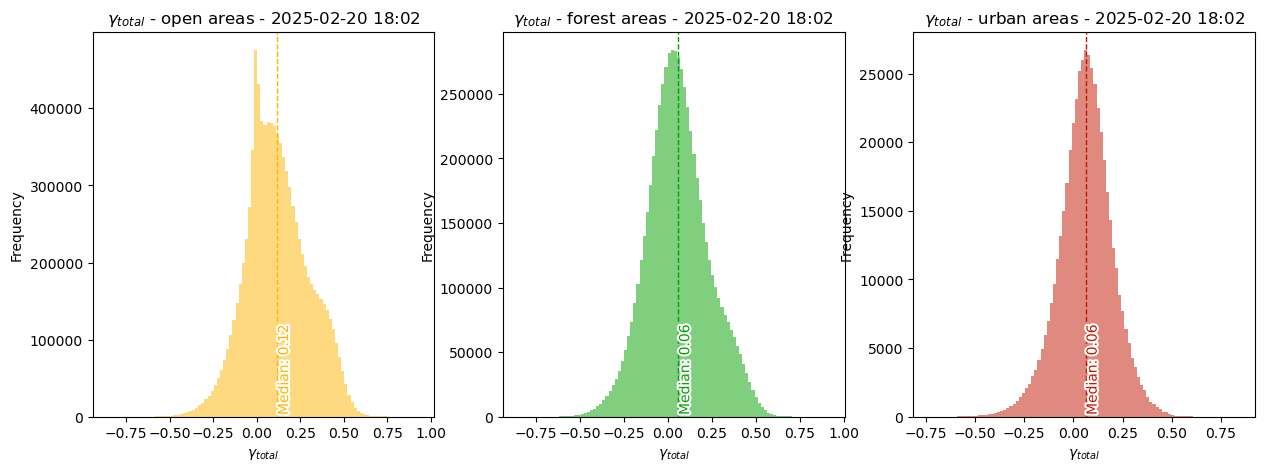

In [ ]:
# takes around 1 minute for seaborn method, 15s for matplotlib method
fig, axs = plt.subplots(1,3, figsize=(15, 5))
fig, axs[0] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="global",
    data_type="diff",
    world_cover_selection='open',
    time_selection="2025-02-20",
    use_seaborn=False,
    fig = fig,
    ax = axs[0],
    show_fig=False
    )
fig, axs[1] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="global",
    data_type="diff",
    world_cover_selection='forest',
    time_selection="2025-02-20",
    use_seaborn=False,
    fig = fig,
    ax = axs[1],
    show_fig=False
    )
fig, axs[2] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="global",
    data_type="diff",
    world_cover_selection='urban',
    time_selection="2025-02-20",
    use_seaborn=False,
    fig = fig,
    ax = axs[2],
    show_fig=False
    )
fig.tight_layout()
plt.show()

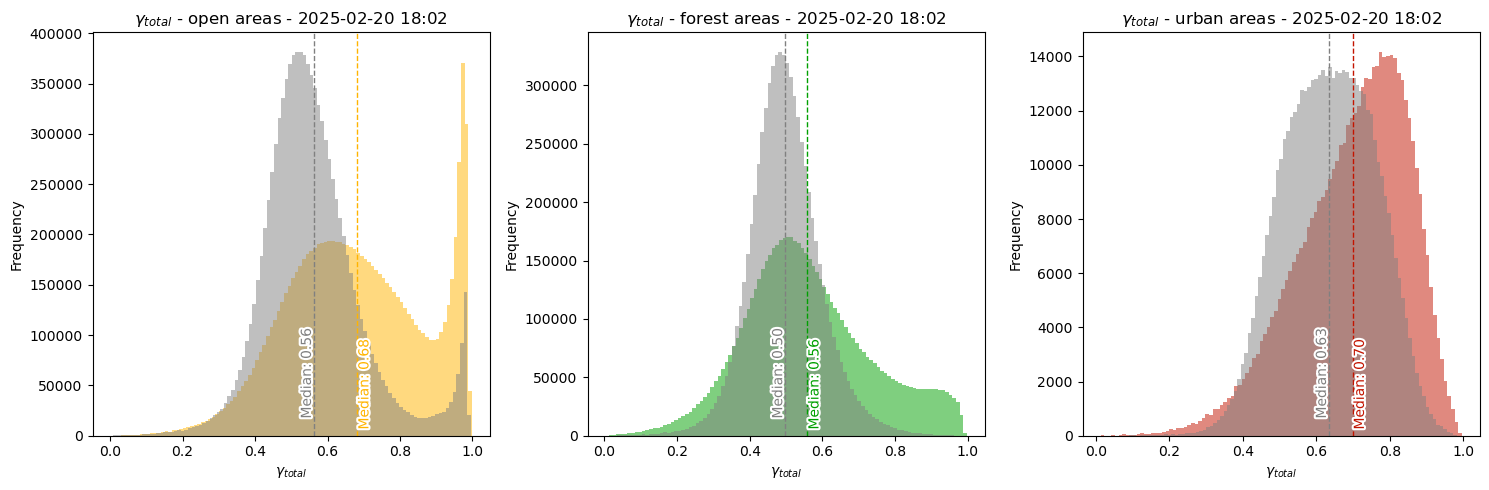

In [41]:
# takes around 1 minute for seaborn method, 15s for matplotlib method
fig, axs = plt.subplots(1,3, figsize=(15, 5))
fig, axs[0] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection='open',
    time_selection="2025-02-20",
    use_seaborn=False,
    fig = fig,
    ax = axs[0],
    show_fig=False
    )
fig, axs[1] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection='forest',
    time_selection="2025-02-20",
    use_seaborn=False,
    fig = fig,
    ax = axs[1],
    show_fig=False
    )
fig, axs[2] = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection='urban',
    time_selection="2025-02-20",
    use_seaborn=False,
    fig = fig,
    ax = axs[2],
    show_fig=False
    )
fig.tight_layout()
plt.show()

And then, the function to combine maps and histograms.

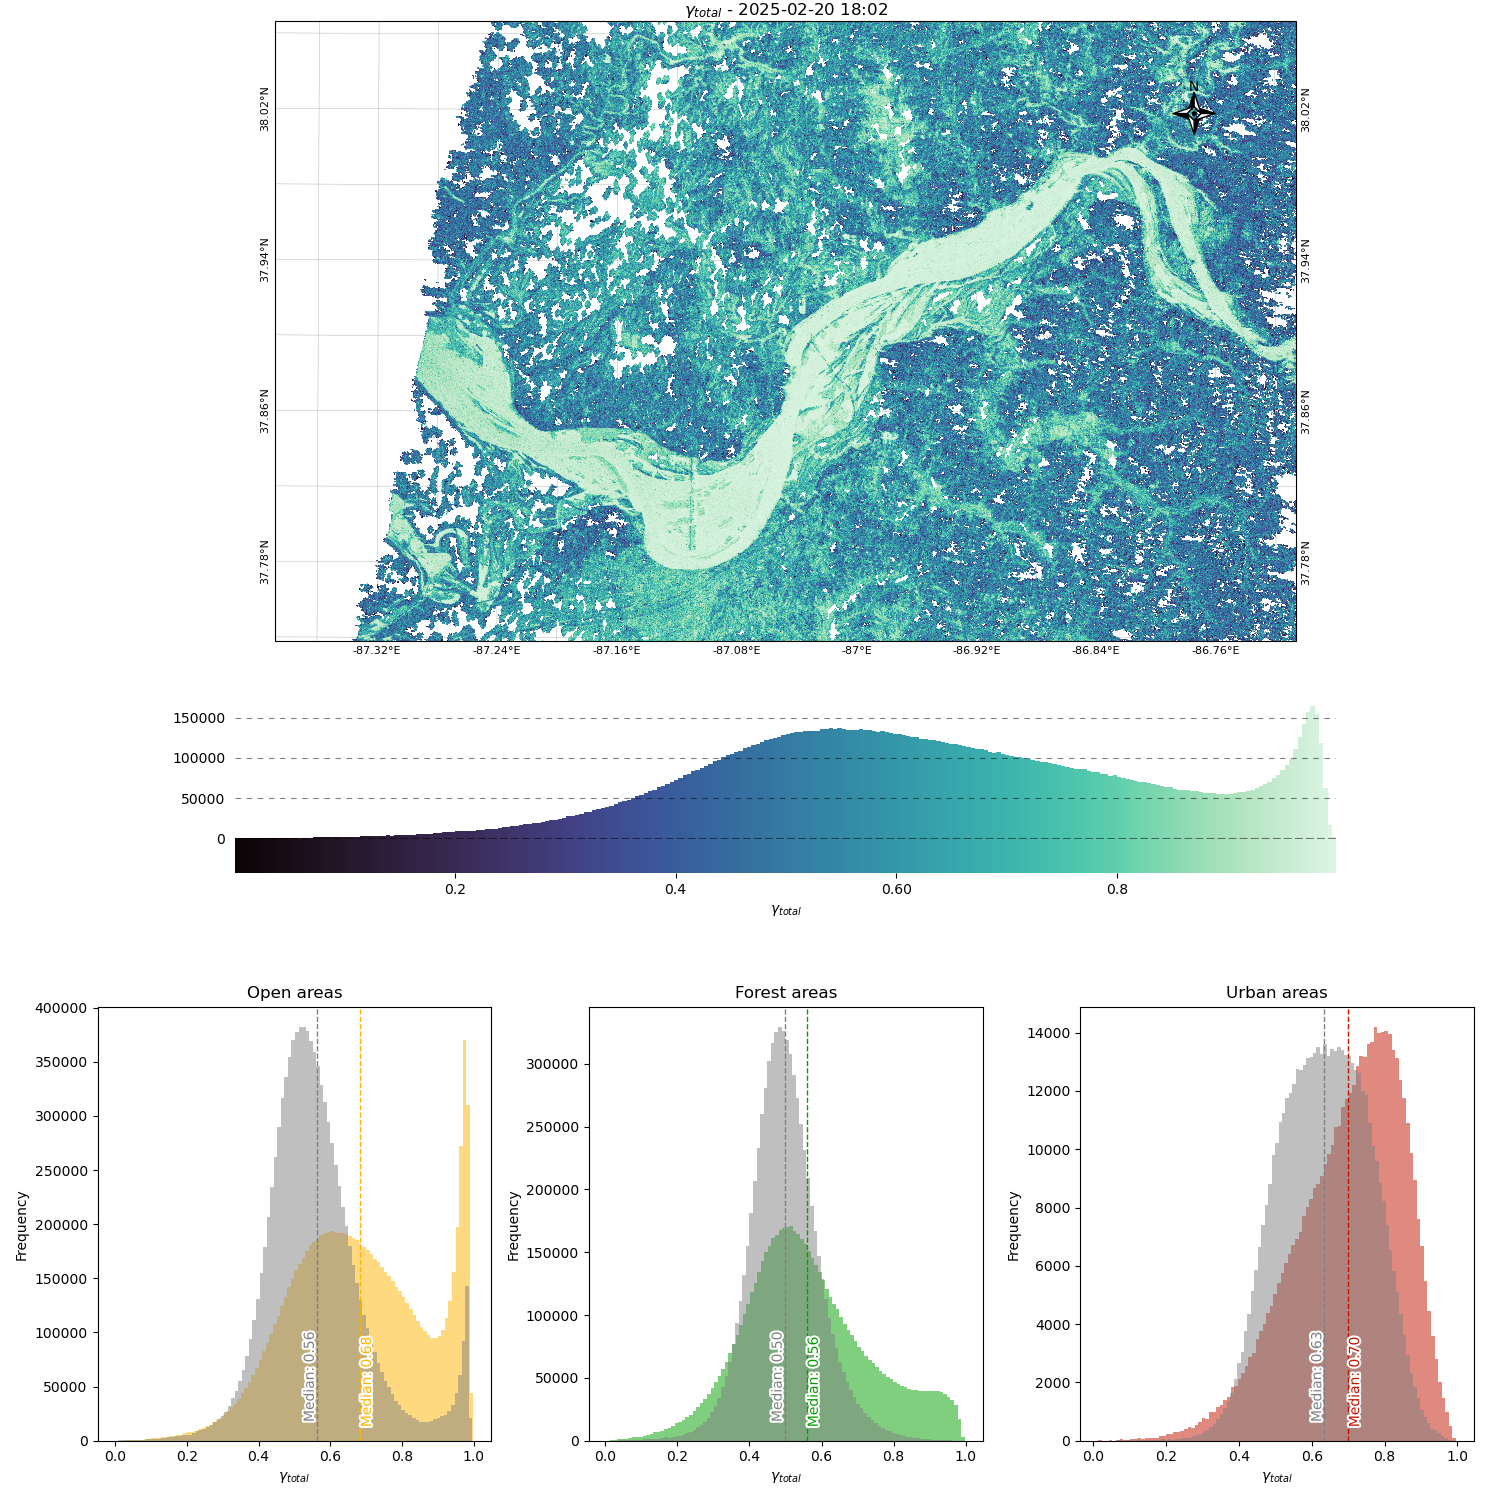

In [31]:
# takes around 1 minute 15s for matplotlib method, 4 minutes for seaborn method
fig, ax = plot_obj.plot_map_with_histogram(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    time_selection="2025-02-20",
    add_bkg=False,
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    use_seaborn=False
    )

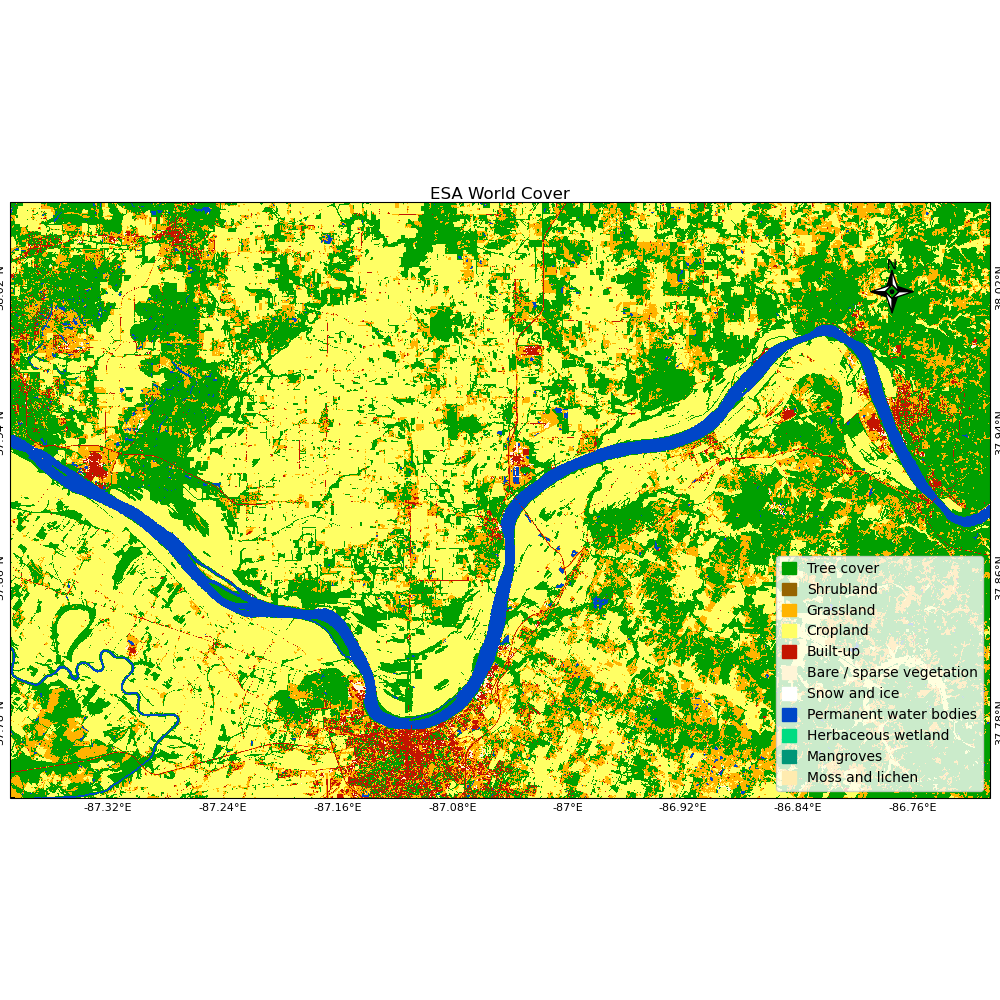

(<Figure size 1000x1000 with 1 Axes>, [<GeoAxes: label='map'>])

In [8]:
plot_obj.plot_auxiliary_data(
    path_to_raster=plot_obj.project.AUX_PATH.joinpath("FM_20250222T000000_S1_POST_fusion_cut_32616_nrow3646_ncol6003.tif"),
    title="FloodML mask from Sentinel-1 image (2025-02-22)",
    is_multiband=False,
    is_worldcover=False,
    vmin=0,
    vmax=1,
)

plot_obj.plot_auxiliary_data(
    path_to_raster=plot_obj.project.AUX_PATH.joinpath("ESA_WC_Fusion_cut_32616_nrow3646_ncol6003.tif"),
    title="ESA World Cover",
    is_multiband=False,
    is_worldcover=True,
)

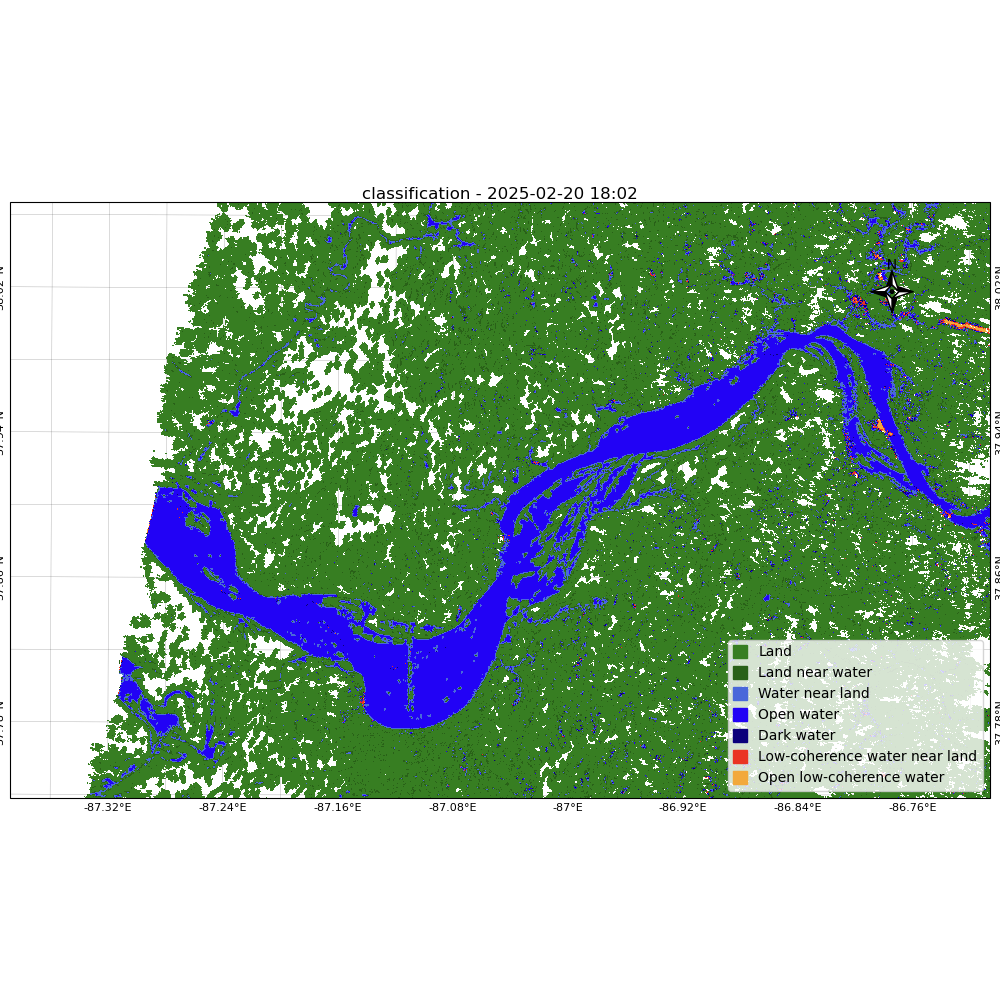

(<Figure size 1000x1000 with 1 Axes>, <GeoAxes: label='map'>)

In [7]:
plot_obj.plot_classification(
    data_area="global",
    time_selection="2025-02-20",
    add_legend=True,
    show_fig=True,
    save_fig=True,
)

In [ ]:
# from skimage.filters import rank
# from skimage.morphology import disk
# import numpy as np

# footprint = disk(2)

# data = plot_obj.swot_collection.swot_flood_rasters.gamma_tot.values[0]
# # data = plot_obj.swot_collection.swot_mean.gamma_tot.values
# cv = data > 0.8
# # norm between 0 and 255
# data = data * 255
# mask = data == np.nan
# data[mask] = 0

# majority_filt = rank.majority(data.astype(np.uint8), footprint=footprint, mask=~mask)
# grad = rank.gradient(data.astype(np.uint8), footprint=footprint, mask=~mask)
# entropy = rank.entropy(data.astype(np.uint8), footprint=footprint, mask=~mask)

# fig, ax = plt.subplots(2,2, figsize=(20, 20))

# im = ax[0,0].imshow(data, cmap=Colormap("seaborn:mako").to_matplotlib())
# plt.colorbar(im, ax=ax[0,0])
# ax[0,0].set_title('Original image')

# im = ax[0,1].imshow(majority_filt, cmap=Colormap("seaborn:mako").to_matplotlib())
# plt.colorbar(im, ax=ax[0,1])
# ax[0,1].set_title('Majority filter')

# im = ax[1,1].imshow(grad, cmap='cividis', vmin=0, vmax=100)
# plt.colorbar(im, ax=ax[1,1])
# ax[1,1].set_title('Gradient')

# im = ax[1,0].imshow(entropy, cmap='magma', vmin=1, vmax=np.amax(entropy))
# plt.colorbar(im, ax=ax[1,0])
# ax[1,0].set_title('Entropy')

# plt.show()

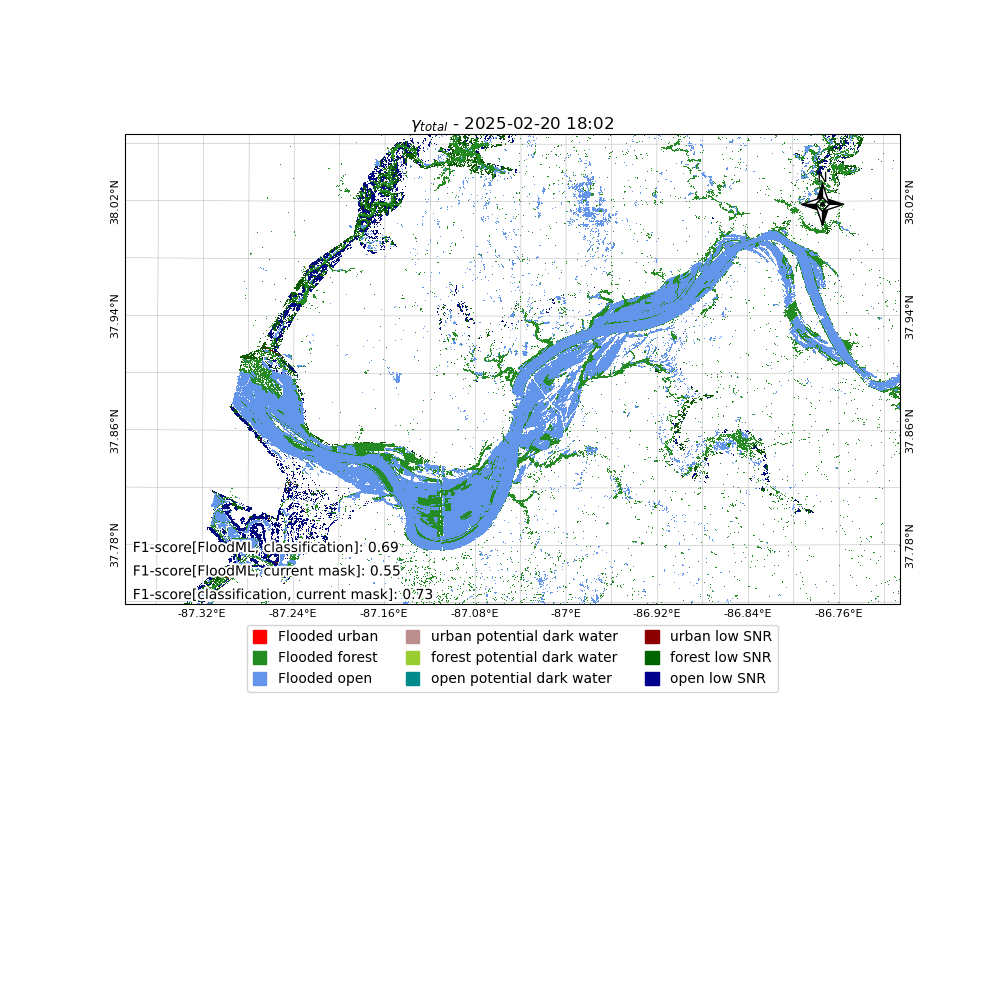

In [8]:
# takes around 5 minutes
fig, ax = plot_obj.plot_map_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    time_selection="2025-02-20",
    comparing_raster_Path=plot_obj.project.AUX_PATH.joinpath("FM_20250222T000000_S1_POST_fusion_cut_32616_nrow3646_ncol6003.tif"),
    thresholds={"urban":-0, "forest":0.7, "open":0.85},
    add_classif_score=True,
    add_uncertainty=True,
    threshold_SNR=0.5,
    threshold_gamma=0.2,
    add_bkg=False,
    add_legend=True,
    )